<a href="https://colab.research.google.com/github/Anand121999/Dl_Assignment1/blob/main/Copy_of_Q1_2_Multitask_CNN_Oxford_Pets_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Practical Assignment — Question 1
## Multi-Task CNN for Breed Classification and Semantic Segmentation

This Google Colab notebook solves Question 1 using the Oxford-IIIT Pet Dataset. One shared CNN encoder feeds two branches: (1) 37-class breed classification and (2) binary pet/background semantic segmentation. The model is built from scratch and uses three encoder blocks and three decoder blocks with skip connections.

## 1. Setup

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 2. Dataset
The Oxford-IIIT Pet dataset provides a breed label and a trimap segmentation annotation. The trimap values are converted to a binary target: pet = 1 and non-pet = 0. Images are resized with bilinear interpolation; masks use nearest-neighbor interpolation so class labels are not interpolated.

In [ ]:
class PetMultiTaskDataset(Dataset):
    def __init__(self, root="./data", split="trainval", image_size=128, download=True):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types=("category", "segmentation"),
            download=download
        )
        self.image_size = image_size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, (label, mask) = self.dataset[idx]

        image = TF.resize(
            image, [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR, antialias=True
        )
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

        mask = TF.resize(
            mask, [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST
        )
        mask = np.array(mask)
        # Oxford-IIIT Pet trimap: 1=pet, 2=background, 3=boundary.
        # For binary segmentation we keep pet as foreground and treat the rest as non-pet.
        mask = (mask == 1).astype(np.float32)
        mask = torch.from_numpy(mask).unsqueeze(0)

        label = torch.tensor(label, dtype=torch.long)
        return image, label, mask

IMAGE_SIZE = 128
BATCH_SIZE = 32

trainval_dataset = PetMultiTaskDataset(split="trainval", image_size=IMAGE_SIZE, download=True)
test_dataset = PetMultiTaskDataset(split="test", image_size=IMAGE_SIZE, download=True)

train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    trainval_dataset, [train_size, val_size], generator=split_generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


100%|██████████| 792M/792M [00:23<00:00, 34.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 14.6MB/s]


Train: 2944
Validation: 736
Test: 3669


In [ ]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

image, label, mask = train_dataset[0]
print("Image shape:", image.shape)
print("Label:", label.item())
print("Mask shape:", mask.shape)
print("Mask values:", torch.unique(mask))


Image shape: torch.Size([3, 128, 128])
Label: 19
Mask shape: torch.Size([1, 128, 128])
Mask values: tensor([0., 1.])


## 3. Check one training example

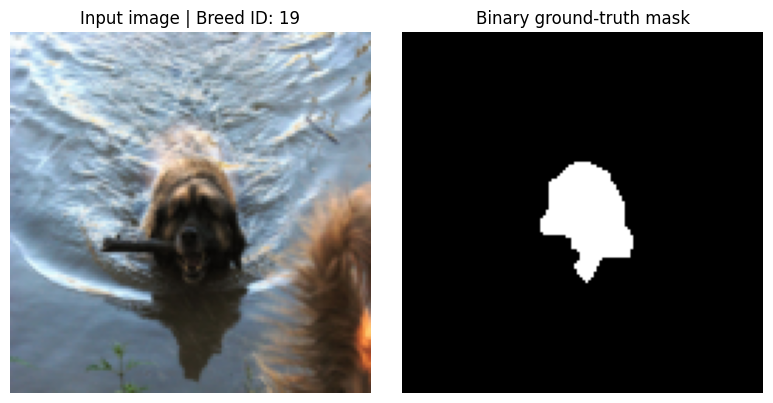

In [ ]:
image, label, mask = train_dataset[0]
display_image = image * 0.5 + 0.5

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(display_image.permute(1, 2, 0).clamp(0, 1))
plt.title(f"Input image | Breed ID: {label.item()}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Binary ground-truth mask")
plt.axis("off")
plt.tight_layout()
plt.show()


## 4. Multi-task CNN architecture
The encoder is shared by both tasks. The classification head uses the bottleneck representation, while the segmentation decoder upsamples back to 128×128 and uses encoder skip connections to recover spatial detail.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class MultiTaskCNN(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()

        # Shared encoder
        self.enc1 = ConvBlock(3, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = ConvBlock(128, 256)

        # Classification head
        self.class_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(256, num_classes)

        # Segmentation decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.segmentation_head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                 # B x 32  x 128 x 128
        e2 = self.enc2(self.pool(e1))     # B x 64  x 64  x 64
        e3 = self.enc3(self.pool(e2))     # B x 128 x 32  x 32
        b = self.bottleneck(self.pool(e3))# B x 256 x 16  x 16

        # Classification branch
        c = self.class_pool(b)
        c = torch.flatten(c, 1)
        class_logits = self.classifier(c)

        # Segmentation branch
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        seg_logits = self.segmentation_head(d1)
        return class_logits, seg_logits


model = MultiTaskCNN(num_classes=37).to(device)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {trainable_params:,}")


MultiTaskCNN(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): ConvBlock(
    (block): S

### Architecture dimensions

| Stage | Input | Output | Main kernel | Activation |
|---|---|---|---|---|
| Encoder 1 | 3×128×128 | 32×128×128 | 3×3 | ReLU |
| Pool 1 | 32×128×128 | 32×64×64 | 2×2 | — |
| Encoder 2 | 32×64×64 | 64×64×64 | 3×3 | ReLU |
| Pool 2 | 64×64×64 | 64×32×32 | 2×2 | — |
| Encoder 3 | 64×32×32 | 128×32×32 | 3×3 | ReLU |
| Pool 3 | 128×32×32 | 128×16×16 | 2×2 | — |
| Bottleneck | 128×16×16 | 256×16×16 | 3×3 | ReLU |
| Classification GAP | 256×16×16 | 256 | — | — |
| Classification FC | 256 | 37 | — | Linear logits |
| Decoder 3 | 256×16×16 | 128×32×32 | 2×2 upsample + 3×3 convs | ReLU |
| Decoder 2 | 128×32×32 | 64×64×64 | 2×2 upsample + 3×3 convs | ReLU |
| Decoder 1 | 64×64×64 | 32×128×128 | 2×2 upsample + 3×3 convs | ReLU |
| Segmentation head | 32×128×128 | 1×128×128 | 1×1 | Logits |

Expected trainable parameter count for this exact model: **1,936,518**.

## 5. Loss functions
Classification uses cross-entropy. Binary segmentation uses BCEWithLogitsLoss plus Dice loss. The two task losses are combined with equal task weights:

**L_total = 1.0 × L_classification + 1.0 × (L_BCE + L_Dice)**

In [ ]:
import torch
import torch.nn as nn


class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        # Convert logits to probabilities
        probs = torch.sigmoid(logits)

        # Flatten each image/mask
        probs = probs.flatten(1)
        targets = targets.flatten(1)

        # Intersection between prediction and ground truth
        intersection = (probs * targets).sum(dim=1)

        # Dice coefficient
        dice = (
            2.0 * intersection + self.smooth
        ) / (
            probs.sum(dim=1)
            + targets.sum(dim=1)
            + self.smooth
        )

        # Dice Loss = 1 - Dice coefficient
        return 1.0 - dice.mean()


# Classification loss
criterion_cls = nn.CrossEntropyLoss()

# Binary segmentation loss
criterion_bce = nn.BCEWithLogitsLoss()

# Dice segmentation loss
criterion_dice = DiceLoss()

# Multi-task loss weights
CLS_WEIGHT = 1.0
SEG_WEIGHT = 1.0

print("Loss functions initialized successfully.")


Loss functions initialized successfully.


## 6. Training configuration

In [ ]:
LEARNING_RATE = 1e-3
NUM_EPOCHS = 25

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print({
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "image_size": IMAGE_SIZE,
    "classification_weight": CLS_WEIGHT,
    "segmentation_weight": SEG_WEIGHT
})


{'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 25, 'image_size': 128, 'classification_weight': 1.0, 'segmentation_weight': 1.0}


## 7. Training and validation functions

In [ ]:
def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    seg_loss_sum = 0.0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, labels, masks in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            class_logits, seg_logits = model(images)

            loss_cls = criterion_cls(class_logits, labels)
            loss_bce = criterion_bce(seg_logits, masks)
            loss_dice = criterion_dice(seg_logits, masks)
            loss_seg = loss_bce + loss_dice
            total_loss = CLS_WEIGHT * loss_cls + SEG_WEIGHT * loss_seg

            if is_training:
                total_loss.backward()
                optimizer.step()

            total_loss_sum += total_loss.item()
            cls_loss_sum += loss_cls.item()
            seg_loss_sum += loss_seg.item()

    n_batches = len(loader)
    return (
        total_loss_sum / n_batches,
        cls_loss_sum / n_batches,
        seg_loss_sum / n_batches
    )


## 8. Train the network
This cell saves the model checkpoint with the lowest validation loss.

In [ ]:
# ============================================================
# CREATE MODEL AND OPTIMIZER
# ============================================================

import torch

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the multi-task CNN
model = MultiTaskCNN(num_classes=37).to(device)

# Training settings
LEARNING_RATE = 1e-3

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Device:", device)
print("Model created successfully.")
print("Optimizer initialized successfully.")

Device: cpu
Model created successfully.
Optimizer initialized successfully.


In [ ]:
print(type(model))
print(type(optimizer))

<class '__main__.MultiTaskCNN'>
<class 'torch.optim.adam.Adam'>


In [ ]:
# ============================================================
# DEFINE DATASET CLASS
# ============================================================

import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


class PetMultiTaskDataset(Dataset):

    def __init__(
        self,
        root="./data",
        split="trainval",
        image_size=128,
        download=True
    ):

        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types=("category", "segmentation"),
            download=download
        )

        self.image_size = image_size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, (label, mask) = self.dataset[idx]

        # ----------------------------------------------------
        # IMAGE PREPROCESSING
        # ----------------------------------------------------

        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True
        )

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )

        # ----------------------------------------------------
        # SEGMENTATION MASK PREPROCESSING
        # ----------------------------------------------------

        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST
        )

        mask = np.array(mask)

        # Oxford-IIIT Pet trimap:
        # 1 = pet
        # 2 = background
        # 3 = boundary
        #
        # Convert to binary:
        # pet = 1
        # background/boundary = 0

        mask = (mask == 1).astype(np.float32)

        mask = torch.from_numpy(mask).unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label, mask


print("PetMultiTaskDataset defined successfully.")

PetMultiTaskDataset defined successfully.


In [ ]:
# ============================================================
# CREATE TRAIN / VALIDATION / TEST DATALOADERS
# ============================================================

import torch
from torch.utils.data import DataLoader, random_split

# -----------------------------
# Create train+validation dataset
# -----------------------------
trainval_dataset = PetMultiTaskDataset(
    root="./data",
    split="trainval",
    image_size=128,
    download=True
)

# -----------------------------
# Create test dataset
# -----------------------------
test_dataset = PetMultiTaskDataset(
    root="./data",
    split="test",
    image_size=128,
    download=True
)

# -----------------------------
# Fixed train-validation split
# -----------------------------
SEED = 42

train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=generator
)

# -----------------------------
# DataLoader settings
# -----------------------------
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# -----------------------------
# Print dataset sizes
# -----------------------------
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("\nDataLoaders created successfully.")

100%|██████████| 792M/792M [00:30<00:00, 25.6MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.72MB/s]


Training samples: 2944
Validation samples: 736
Test samples: 3669

DataLoaders created successfully.


In [ ]:
# ============================================================
# CHECK ONE BATCH
# ============================================================

images, labels, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Masks shape:", masks.shape)
print("Mask values:", torch.unique(masks))

Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
Masks shape: torch.Size([32, 1, 128, 128])
Mask values: tensor([0., 1.])


In [ ]:
# ============================================================
# DEFINE TRAINING / VALIDATION FUNCTION
# ============================================================

def run_epoch(model, loader, optimizer=None):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    seg_loss_sum = 0.0

    for images, labels, masks in loader:

        images = images.to(device)
        labels = labels.to(device)
        masks = masks.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):

            # Forward pass
            class_logits, seg_logits = model(images)

            # Classification loss
            cls_loss = criterion_cls(
                class_logits,
                labels
            )

            # Segmentation losses
            bce_loss = criterion_bce(
                seg_logits,
                masks
            )

            dice_loss = criterion_dice(
                seg_logits,
                masks
            )

            seg_loss = bce_loss + dice_loss

            # Combined multi-task loss
            total_loss = (
                CLS_WEIGHT * cls_loss
                + SEG_WEIGHT * seg_loss
            )

            # Backpropagation only during training
            if is_training:
                total_loss.backward()
                optimizer.step()

        total_loss_sum += total_loss.item()
        cls_loss_sum += cls_loss.item()
        seg_loss_sum += seg_loss.item()

    num_batches = len(loader)

    return (
        total_loss_sum / num_batches,
        cls_loss_sum / num_batches,
        seg_loss_sum / num_batches
    )


print("run_epoch function defined successfully.")

run_epoch function defined successfully.


In [ ]:
train_total, train_cls, train_seg = run_epoch(
    model,
    train_loader,
    optimizer
)

print("Train Total Loss:", train_total)
print("Train Classification Loss:", train_cls)
print("Train Segmentation Loss:", train_seg)

Train Total Loss: 4.54118335765341
Train Classification Loss: 3.527589271897855
Train Segmentation Loss: 1.013594081868296


In [3]:
# ============================================================
# DEFINE TRAINING / VALIDATION FUNCTION
# ============================================================

def run_epoch(model, loader, optimizer=None):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    seg_loss_sum = 0.0

    for images, labels, masks in loader:

        images = images.to(device)
        labels = labels.to(device)
        masks = masks.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):

            # Forward pass
            class_logits, seg_logits = model(images)

            # Classification loss
            cls_loss = criterion_cls(
                class_logits,
                labels
            )

            # Segmentation losses
            bce_loss = criterion_bce(
                seg_logits,
                masks
            )

            dice_loss = criterion_dice(
                seg_logits,
                masks
            )

            seg_loss = bce_loss + dice_loss

            # Combined multi-task loss
            total_loss = (
                CLS_WEIGHT * cls_loss
                + SEG_WEIGHT * seg_loss
            )

            # Backpropagation
            if is_training:
                total_loss.backward()
                optimizer.step()

        total_loss_sum += total_loss.item()
        cls_loss_sum += cls_loss.item()
        seg_loss_sum += seg_loss.item()

    num_batches = len(loader)

    return (
        total_loss_sum / num_batches,
        cls_loss_sum / num_batches,
        seg_loss_sum / num_batches
    )


print("run_epoch function defined successfully.")

run_epoch function defined successfully.


In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [8]:
# ============================================================
# DEFINE MODEL + CREATE MODEL + OPTIMIZER
# ============================================================

import torch
import torch.nn as nn


# ------------------------------------------------------------
# Convolution Block
# ------------------------------------------------------------
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ------------------------------------------------------------
# Multi-Task CNN
# ------------------------------------------------------------
class MultiTaskCNN(nn.Module):

    def __init__(self, num_classes=37):
        super().__init__()

        # =========================
        # Shared Encoder
        # =========================

        self.enc1 = ConvBlock(3, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.bottleneck = ConvBlock(
            128,
            256
        )

        # =========================
        # Classification Branch
        # =========================

        self.class_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Linear(
            256,
            num_classes
        )

        # =========================
        # Segmentation Branch
        # =========================

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = ConvBlock(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = ConvBlock(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = ConvBlock(
            64,
            32
        )

        self.segmentation_head = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # -------------------------
        # Encoder
        # -------------------------

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        b = self.bottleneck(
            self.pool(e3)
        )

        # -------------------------
        # Classification
        # -------------------------

        c = self.class_pool(b)

        c = torch.flatten(
            c,
            1
        )

        class_logits = self.classifier(c)

        # -------------------------
        # Segmentation Decoder
        # -------------------------

        d3 = self.up3(b)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        seg_logits = self.segmentation_head(d1)

        return class_logits, seg_logits


# ============================================================
# GPU DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# CREATE MODEL
# ============================================================

model = MultiTaskCNN(
    num_classes=37
).to(device)


# ============================================================
# CREATE OPTIMIZER
# ============================================================

LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# CHECK MODEL
# ============================================================

num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nMultiTaskCNN defined successfully.")
print("Model created successfully.")
print("Optimizer created successfully.")
print(f"Trainable parameters: {num_params:,}")

Using device: cuda
GPU: Tesla T4

MultiTaskCNN defined successfully.
Model created successfully.
Optimizer created successfully.
Trainable parameters: 1,936,518


In [10]:
# ============================================================
# RECREATE DATASET + DATALOADERS
# ============================================================

import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


# ------------------------------------------------------------
# Dataset class
# ------------------------------------------------------------

class PetMultiTaskDataset(Dataset):

    def __init__(
        self,
        root="./data",
        split="trainval",
        image_size=128,
        download=True
    ):

        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types=("category", "segmentation"),
            download=download
        )

        self.image_size = image_size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, (label, mask) = self.dataset[idx]

        # Resize image
        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True
        )

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )

        # Resize mask
        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST
        )

        mask = np.array(mask)

        # Binary mask:
        # 1 = pet
        # 0 = background/boundary
        mask = (mask == 1).astype(np.float32)

        mask = torch.from_numpy(mask).unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label, mask


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

IMAGE_SIZE = 128

trainval_dataset = PetMultiTaskDataset(
    root="./data",
    split="trainval",
    image_size=IMAGE_SIZE,
    download=True
)

test_dataset = PetMultiTaskDataset(
    root="./data",
    split="test",
    image_size=IMAGE_SIZE,
    download=True
)


# ------------------------------------------------------------
# Train / validation split
# ------------------------------------------------------------

SEED = 42

train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=generator
)


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ------------------------------------------------------------
# Check
# ------------------------------------------------------------

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("\nDataLoaders recreated successfully.")

100%|██████████| 792M/792M [00:36<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.25MB/s]


Training samples: 2944
Validation samples: 736
Test samples: 3669

DataLoaders recreated successfully.


In [11]:
# ============================================================
# DEFINE LOSS FUNCTIONS
# ============================================================

import torch
import torch.nn as nn


class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.flatten(1)
        targets = targets.flatten(1)

        intersection = (probs * targets).sum(dim=1)

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            probs.sum(dim=1)
            + targets.sum(dim=1)
            + self.smooth
        )

        return 1.0 - dice.mean()


# Classification loss
criterion_cls = nn.CrossEntropyLoss()

# Segmentation losses
criterion_bce = nn.BCEWithLogitsLoss()
criterion_dice = DiceLoss()

# Multi-task weights
CLS_WEIGHT = 1.0
SEG_WEIGHT = 1.0

print("Loss functions initialized successfully.")

Loss functions initialized successfully.


In [12]:
# ============================================================
# DEFINE TRAINING / VALIDATION FUNCTION
# ============================================================

def run_epoch(model, loader, optimizer=None):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    seg_loss_sum = 0.0

    for images, labels, masks in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):

            class_logits, seg_logits = model(images)

            cls_loss = criterion_cls(
                class_logits,
                labels
            )

            bce_loss = criterion_bce(
                seg_logits,
                masks
            )

            dice_loss = criterion_dice(
                seg_logits,
                masks
            )

            seg_loss = bce_loss + dice_loss

            total_loss = (
                CLS_WEIGHT * cls_loss
                + SEG_WEIGHT * seg_loss
            )

            if is_training:
                total_loss.backward()
                optimizer.step()

        total_loss_sum += total_loss.item()
        cls_loss_sum += cls_loss.item()
        seg_loss_sum += seg_loss.item()

    n_batches = len(loader)

    return (
        total_loss_sum / n_batches,
        cls_loss_sum / n_batches,
        seg_loss_sum / n_batches
    )

print("run_epoch defined successfully.")

run_epoch defined successfully.


In [13]:
print("Device:", device)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Model:", type(model).__name__)
print("Optimizer:", type(optimizer).__name__)

Device: cuda
Train batches: 92
Validation batches: 23
Model: MultiTaskCNN
Optimizer: Adam


In [14]:
# ============================================================
# FULL TRAINING - 25 EPOCHS
# ============================================================

NUM_EPOCHS = 25

history = {
    "train_total": [],
    "val_total": [],
    "train_cls": [],
    "val_cls": [],
    "train_seg": [],
    "val_seg": []
}

best_val_loss = float("inf")
BEST_MODEL_PATH = "best_multitask_q1.pth"

for epoch in range(1, NUM_EPOCHS + 1):

    train_total, train_cls, train_seg = run_epoch(
        model,
        train_loader,
        optimizer
    )

    val_total, val_cls, val_seg = run_epoch(
        model,
        val_loader,
        optimizer=None
    )

    history["train_total"].append(train_total)
    history["val_total"].append(val_total)

    history["train_cls"].append(train_cls)
    history["val_cls"].append(val_cls)

    history["train_seg"].append(train_seg)
    history["val_seg"].append(val_seg)

    if val_total < best_val_loss:

        best_val_loss = val_total

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        marker = " <-- Best model saved"

    else:
        marker = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Total: {train_total:.4f} | "
        f"Val Total: {val_total:.4f} | "
        f"Train Cls: {train_cls:.4f} | "
        f"Val Cls: {val_cls:.4f} | "
        f"Train Seg: {train_seg:.4f} | "
        f"Val Seg: {val_seg:.4f}"
        f"{marker}"
    )

# Load best model after training
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

print("\nTraining completed successfully.")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best model loaded from: {BEST_MODEL_PATH}")

Epoch 01/25 | Train Total: 4.4896 | Val Total: 4.4730 | Train Cls: 3.5068 | Val Cls: 3.6085 | Train Seg: 0.9828 | Val Seg: 0.8645 <-- Best model saved
Epoch 02/25 | Train Total: 3.9646 | Val Total: 4.2711 | Train Cls: 3.2385 | Val Cls: 3.5535 | Train Seg: 0.7261 | Val Seg: 0.7176 <-- Best model saved
Epoch 03/25 | Train Total: 3.6440 | Val Total: 4.6222 | Train Cls: 2.9886 | Val Cls: 3.9073 | Train Seg: 0.6554 | Val Seg: 0.7148
Epoch 04/25 | Train Total: 3.4278 | Val Total: 3.6513 | Train Cls: 2.8104 | Val Cls: 3.0787 | Train Seg: 0.6174 | Val Seg: 0.5726 <-- Best model saved
Epoch 05/25 | Train Total: 3.2343 | Val Total: 3.4094 | Train Cls: 2.6665 | Val Cls: 2.8207 | Train Seg: 0.5678 | Val Seg: 0.5887 <-- Best model saved
Epoch 06/25 | Train Total: 3.1000 | Val Total: 3.3797 | Train Cls: 2.5343 | Val Cls: 2.8442 | Train Seg: 0.5657 | Val Seg: 0.5355 <-- Best model saved
Epoch 07/25 | Train Total: 2.9116 | Val Total: 3.5053 | Train Cls: 2.3753 | Val Cls: 2.9565 | Train Seg: 0.5363 | V

## 9. Training and validation loss curves

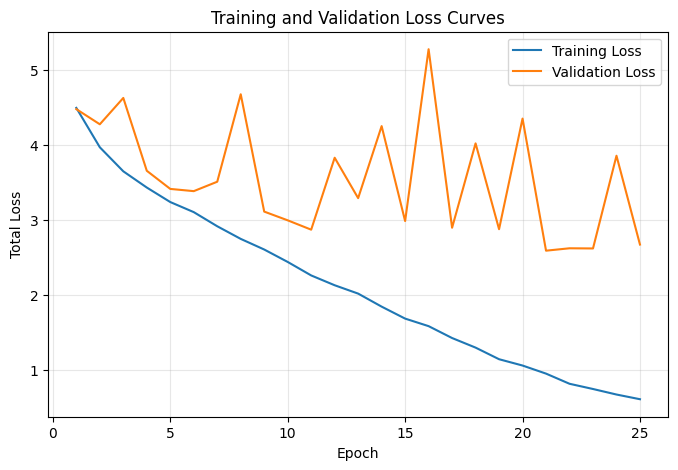

In [15]:
# ============================================================
# PLOT TRAINING AND VALIDATION LOSS CURVES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_total"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_total"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 10. Classification evaluation
The required test classification outputs are overall accuracy and a 37-class confusion matrix.

In [16]:
# ============================================================
# TEST CLASSIFICATION ACCURACY
# ============================================================

model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels, masks in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        class_logits, _ = model(images)

        # Predicted class
        predictions = torch.argmax(
            class_logits,
            dim=1
        )

        # Count correct predictions
        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        # Store for confusion matrix
        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

# Classification accuracy
test_accuracy = correct / total

print(
    f"Test Classification Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Classification Accuracy: 35.43%


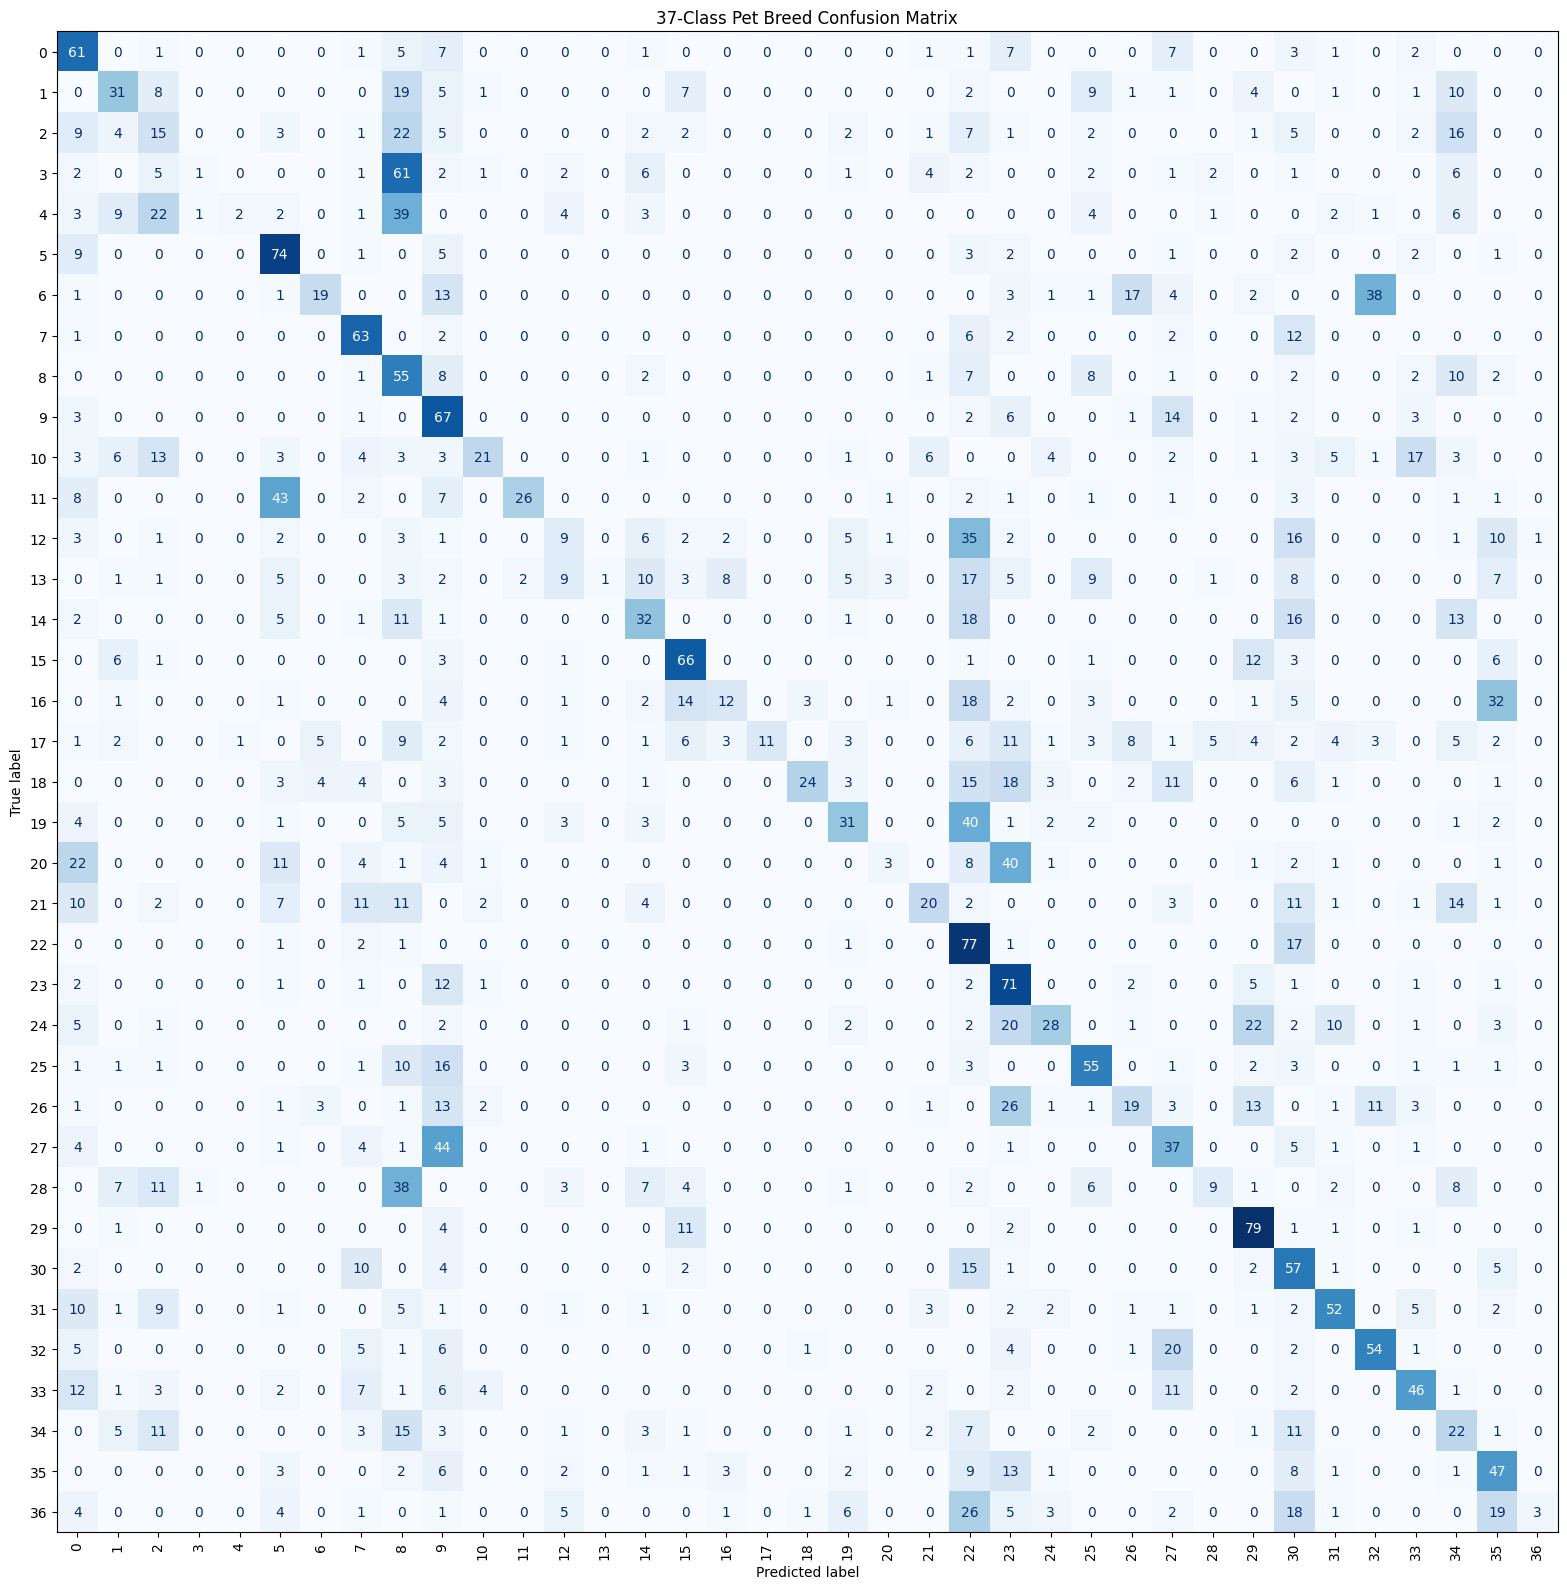

In [17]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=np.arange(37)
)

fig, ax = plt.subplots(
    figsize=(16, 16)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(37)
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

plt.title("37-Class Pet Breed Confusion Matrix")

plt.tight_layout()
plt.show()

## 11. Segmentation metrics
IoU = intersection / union. Dice = 2 × intersection / (prediction area + target area). Predictions are converted from logits to probabilities with sigmoid and thresholded at 0.5.

In [18]:
# ============================================================
# 12. SEGMENTATION EVALUATION
# ============================================================

import numpy as np

# ------------------------------------------------------------
# IoU function
# ------------------------------------------------------------

def compute_iou(pred, target, eps=1e-6):

    pred = pred.float()
    target = target.float()

    intersection = (
        pred * target
    ).sum(dim=(1, 2, 3))

    union = (
        pred + target - pred * target
    ).sum(dim=(1, 2, 3))

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    return iou


# ------------------------------------------------------------
# Dice function
# ------------------------------------------------------------

def compute_dice(pred, target, eps=1e-6):

    pred = pred.float()
    target = target.float()

    intersection = (
        pred * target
    ).sum(dim=(1, 2, 3))

    dice = (
        2.0 * intersection + eps
    ) / (
        pred.sum(dim=(1, 2, 3))
        + target.sum(dim=(1, 2, 3))
        + eps
    )

    return dice


# ------------------------------------------------------------
# Evaluate on test set
# ------------------------------------------------------------

model.eval()

all_ious = []
all_dices = []

with torch.no_grad():

    for images, labels, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        _, seg_logits = model(images)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(seg_logits)

        # Convert probabilities to binary mask
        pred_masks = (
            probabilities >= 0.5
        ).float()

        # Compute IoU
        iou = compute_iou(
            pred_masks,
            masks
        )

        # Compute Dice
        dice = compute_dice(
            pred_masks,
            masks
        )

        all_ious.extend(
            iou.cpu().numpy()
        )

        all_dices.extend(
            dice.cpu().numpy()
        )


# ------------------------------------------------------------
# Mean results
# ------------------------------------------------------------

mean_iou = np.mean(all_ious)
mean_dice = np.mean(all_dices)

print(
    f"Mean Test IoU: {mean_iou:.4f}"
)

print(
    f"Mean Test Dice: {mean_dice:.4f}"
)

Mean Test IoU: 0.7407
Mean Test Dice: 0.8404


## 12. Qualitative analysis examples
The assignment asks for at least five test examples, including successful and unsuccessful cases. The next two cells rank test images by IoU and show three best and three worst cases.

In [19]:
# ============================================================
# 13. QUALITATIVE ANALYSIS
# ============================================================

def get_segmentation_examples(model, dataset, device):

    model.eval()
    results = []

    with torch.no_grad():

        for idx in range(len(dataset)):

            image, label, gt_mask = dataset[idx]

            x = image.unsqueeze(0).to(device)
            target = gt_mask.unsqueeze(0).to(device)

            _, seg_logits = model(x)

            pred_mask = (
                torch.sigmoid(seg_logits) >= 0.5
            ).float()

            iou = compute_iou(
                pred_mask,
                target
            ).item()

            results.append(
                (iou, idx)
            )

    results.sort(
        key=lambda x: x[0]
    )

    return results


segmentation_results = get_segmentation_examples(
    model,
    test_dataset,
    device
)

# 3 worst + 3 best examples
worst_examples = segmentation_results[:3]
best_examples = segmentation_results[-3:]

print("Best examples:", best_examples)
print("Worst examples:", worst_examples)

Best examples: [(0.9648682475090027, 905), (0.9676575064659119, 2305), (0.9683812856674194, 675)]
Worst examples: [(6.966699439558965e-11, 2308), (7.229089549198875e-11, 1858), (1.3810247390111385e-10, 1690)]


In [22]:
# ============================================================
# VISUALIZE BEST AND WORST SEGMENTATION EXAMPLES
# ============================================================

import matplotlib.pyplot as plt


def show_examples(model, dataset, examples, device, title):

    model.eval()
    n = len(examples)

    plt.figure(figsize=(12, 4 * n))

    with torch.no_grad():

        for row, (iou_score, idx) in enumerate(examples):

            image, label, gt_mask = dataset[idx]

            x = image.unsqueeze(0).to(device)

            # Model prediction
            _, seg_logits = model(x)

            pred_mask = (
                torch.sigmoid(seg_logits) >= 0.5
            ).float()

            pred_mask = (
                pred_mask
                .squeeze()
                .cpu()
                .numpy()
            )

            # Undo image normalization for display
            display_image = image * 0.5 + 0.5

            # --------------------------------
            # Input image
            # --------------------------------
            plt.subplot(n, 3, row * 3 + 1)

            plt.imshow(
                display_image
                .permute(1, 2, 0)
                .clamp(0, 1)
            )

            plt.title(
                f"Input Image\nIndex={idx}"
            )

            plt.axis("off")

            # --------------------------------
            # Ground-truth mask
            # --------------------------------
            plt.subplot(n, 3, row * 3 + 2)

            plt.imshow(
                gt_mask.squeeze(),
                cmap="gray"
            )

            plt.title(
                "Ground-Truth Mask"
            )

            plt.axis("off")

            # --------------------------------
            # Predicted mask
            # --------------------------------
            plt.subplot(n, 3, row * 3 + 3)

            plt.imshow(
                pred_mask,
                cmap="gray"
            )

            plt.title(
                f"Predicted Mask\nIoU={iou_score:.3f}"
            )

            plt.axis("off")

    plt.suptitle(
        title,
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

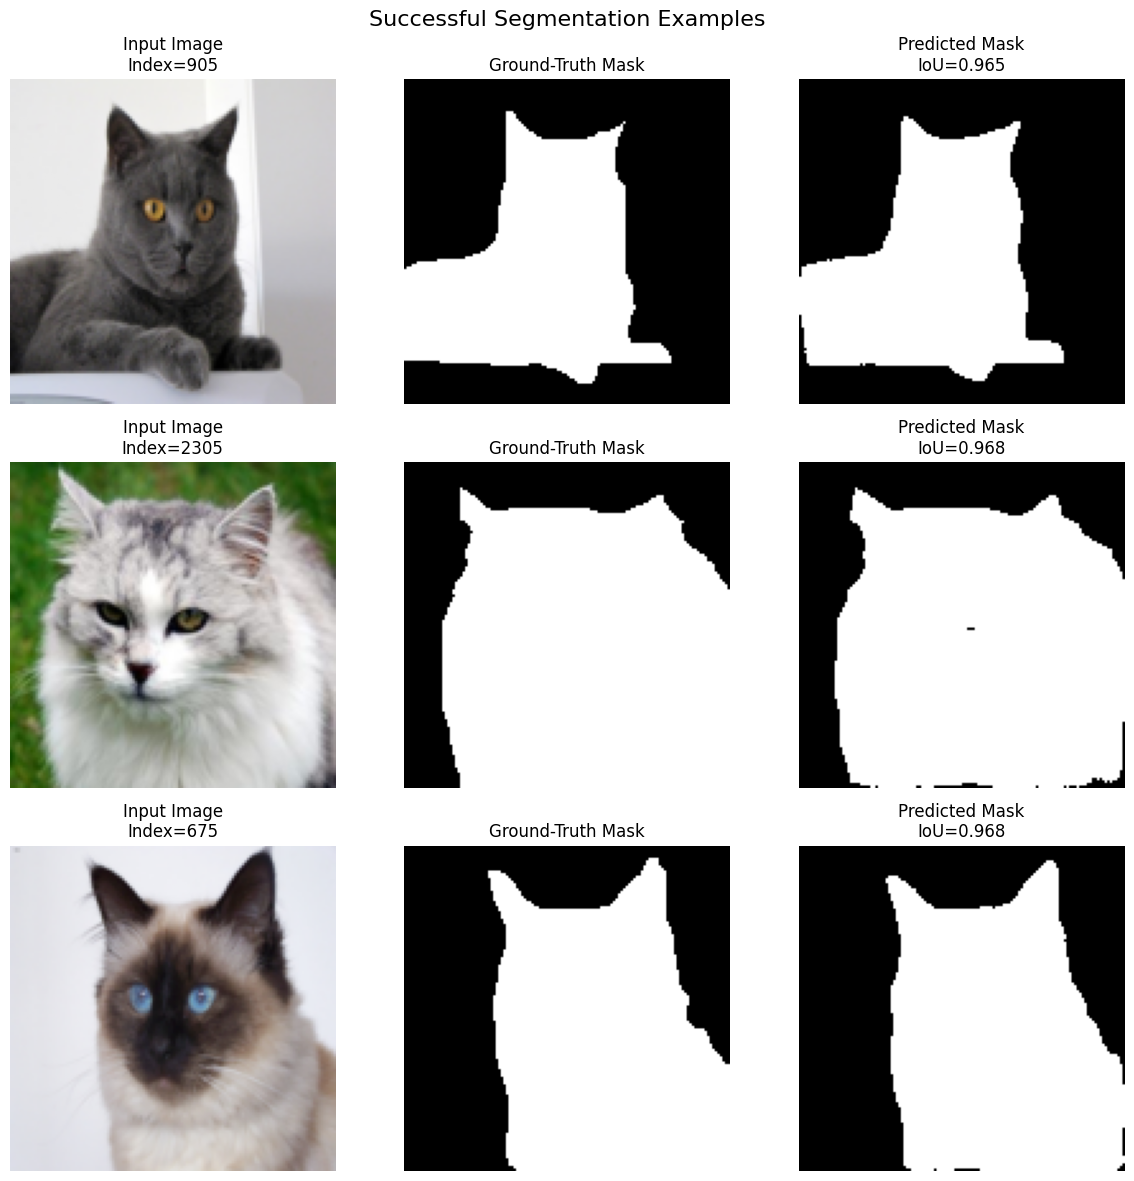

In [23]:
show_examples(
    model,
    test_dataset,
    best_examples,
    device,
    "Successful Segmentation Examples"
)

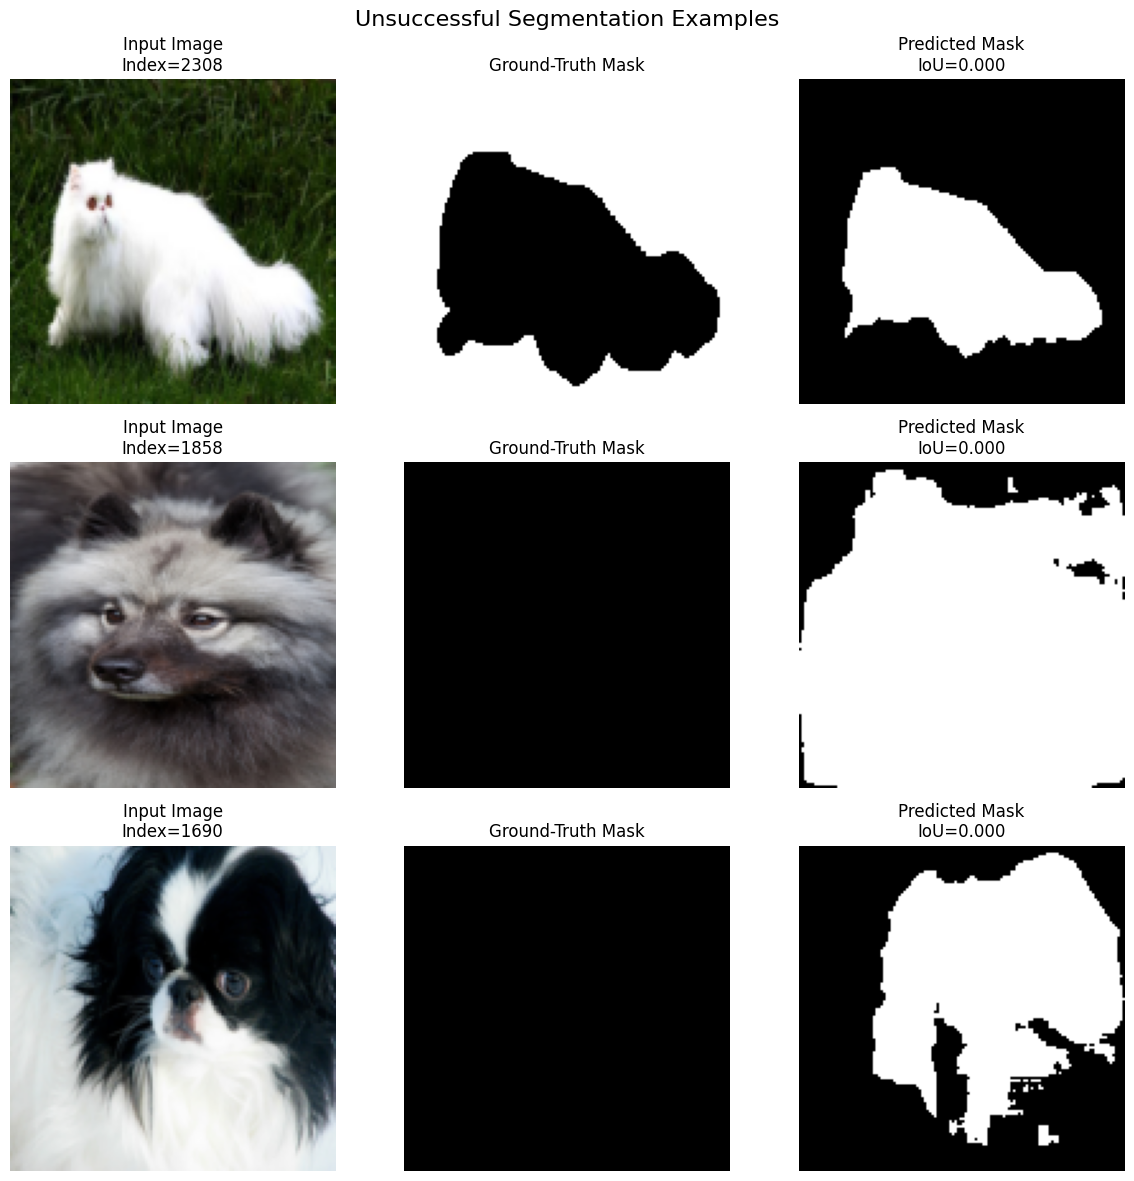

In [24]:
show_examples(
    model,
    test_dataset,
    worst_examples,
    device,
    "Unsuccessful Segmentation Examples"
)

In [26]:
# ============================================================
# CHECK WORST-CASE MASKS
# ============================================================

for iou_score, idx in worst_examples:

    image, label, gt_mask = test_dataset[idx]

    x = image.unsqueeze(0).to(device)

    with torch.no_grad():
        _, seg_logits = model(x)

        pred_mask = (
            torch.sigmoid(seg_logits) >= 0.5
        ).float().cpu().squeeze()

    print(f"\nIndex: {idx}")
    print(f"IoU: {iou_score:.8f}")

    print(
        "Ground-truth unique values:",
        torch.unique(gt_mask)
    )

    print(
        "Predicted unique values:",
        torch.unique(pred_mask)
    )

    print(
        "Ground-truth foreground fraction:",
        gt_mask.float().mean().item()
    )

    print(
        "Predicted foreground fraction:",
        pred_mask.float().mean().item()
    )


Index: 2308
IoU: 0.00000000
Ground-truth unique values: tensor([0., 1.])
Predicted unique values: tensor([0., 1.])
Ground-truth foreground fraction: 0.60009765625
Predicted foreground fraction: 0.2760009765625

Index: 1858
IoU: 0.00000000
Ground-truth unique values: tensor([0.])
Predicted unique values: tensor([0., 1.])
Ground-truth foreground fraction: 0.0
Predicted foreground fraction: 0.84429931640625

Index: 1690
IoU: 0.00000000
Ground-truth unique values: tensor([0.])
Predicted unique values: tensor([0., 1.])
Ground-truth foreground fraction: 0.0
Predicted foreground fraction: 0.44195556640625


In [27]:
# ============================================================
# SELECT VALID WORST SEGMENTATION EXAMPLES
# Ignore samples with empty ground-truth masks
# ============================================================

valid_results = []

for iou_score, idx in segmentation_results:

    image, label, gt_mask = test_dataset[idx]

    # Keep only samples that actually contain foreground pixels
    if gt_mask.sum().item() > 0:
        valid_results.append((iou_score, idx))

# Three worst valid examples
worst_examples_valid = valid_results[:3]

# Three best valid examples
best_examples_valid = valid_results[-3:]

print("Best valid examples:")
print(best_examples_valid)

print("\nWorst valid examples:")
print(worst_examples_valid)

Best valid examples:
[(0.9648682475090027, 905), (0.9676575064659119, 2305), (0.9683812856674194, 675)]

Worst valid examples:
[(6.966699439558965e-11, 2308), (3.759398570224448e-09, 3137), (0.015963513404130936, 2107)]


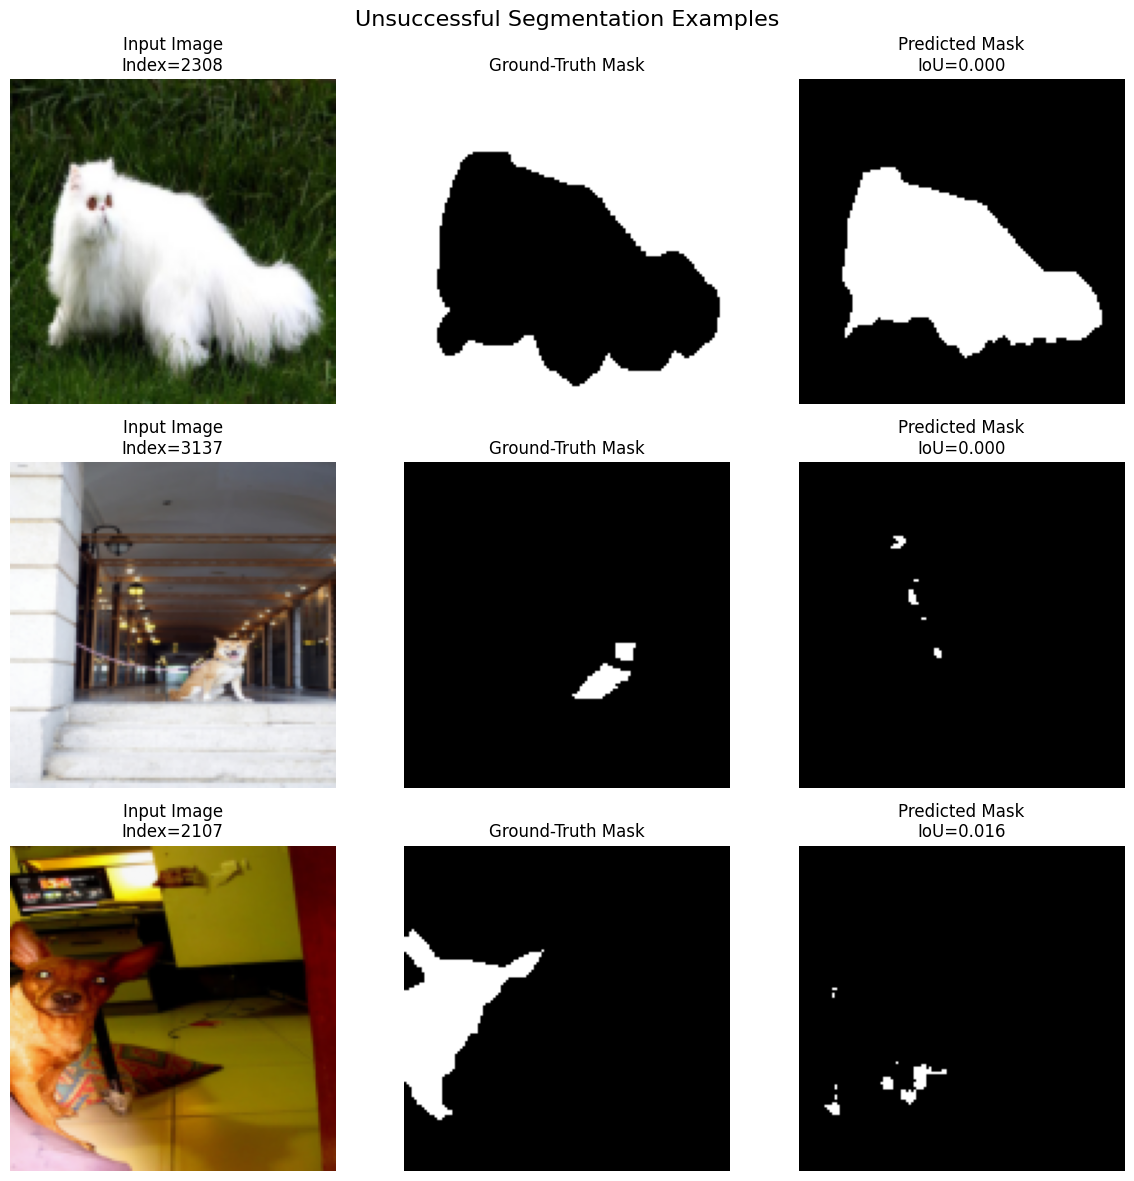

In [28]:
show_examples(
    model,
    test_dataset,
    worst_examples_valid,
    device,
    "Unsuccessful Segmentation Examples"
)

## 13. Final result summary

In [29]:
# ============================================================
# 14. FINAL RESULTS SUMMARY
# ============================================================

print("QUESTION 1 FINAL RESULTS")
print("=" * 45)

print(f"Best Validation Loss          : {best_val_loss:.4f}")
print(f"Test Classification Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Mean Test IoU                 : {mean_iou:.4f}")
print(f"Mean Test Dice                : {mean_dice:.4f}")

print("=" * 45)

QUESTION 1 FINAL RESULTS
Best Validation Loss          : 2.5860
Test Classification Accuracy  : 35.43%
Mean Test IoU                 : 0.7407
Mean Test Dice                : 0.8404


## 14. What to write in the report

**Architecture:** A shared CNN encoder with three convolutional blocks and a bottleneck was used. Each block has two 3×3 convolutions, batch normalization, and ReLU. The classification branch applies global average pooling and a linear 37-class classifier. The segmentation branch contains three transposed-convolution upsampling stages with skip connections from the encoder, followed by a 1×1 output convolution.

**Loss:** Cross-entropy is used for breed classification. Segmentation uses BCEWithLogitsLoss + Dice loss. The task-level weights are 1.0 for classification and 1.0 for segmentation.

**Training:** Adam optimizer, learning rate 0.001, batch size 32, 25 epochs, 128×128 images. The best checkpoint is selected using validation loss.

**Results:** Copy the classification accuracy, mean IoU, and mean Dice produced by the final result cell. Add the loss plots, confusion matrix, and successful/unsuccessful segmentation examples. Do not invent values before running the experiment.

Question 2 Experiment B — Geometric Augmentation

In [31]:
# ============================================================
# QUESTION 2 - EXPERIMENT B
# GEOMETRIC AUGMENTATION
# ============================================================

import random
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.transforms import RandomResizedCrop


class PetMultiTaskDatasetAug(Dataset):

    def __init__(
        self,
        root="./data",
        split="trainval",
        image_size=128,
        download=True,
        augment=False
    ):

        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types=("category", "segmentation"),
            download=download
        )

        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, (label, mask) = self.dataset[idx]

        # ----------------------------------------------------
        # GEOMETRIC AUGMENTATION
        # Must be applied identically to image and mask
        # ----------------------------------------------------
        if self.augment:

            # 1. Random horizontal flip
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # 2. Random rotation
            angle = random.uniform(-15, 15)

            image = TF.rotate(
                image,
                angle=angle,
                interpolation=InterpolationMode.BILINEAR,
                fill=0
            )

            mask = TF.rotate(
                mask,
                angle=angle,
                interpolation=InterpolationMode.NEAREST,
                fill=2
            )

            # 3. Random resized crop
            i, j, h, w = RandomResizedCrop.get_params(
                image,
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1)
            )

            image = TF.resized_crop(
                image,
                i, j, h, w,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
                antialias=True
            )

            mask = TF.resized_crop(
                mask,
                i, j, h, w,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.NEAREST
            )

        else:

            image = TF.resize(
                image,
                [self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
                antialias=True
            )

            mask = TF.resize(
                mask,
                [self.image_size, self.image_size],
                interpolation=InterpolationMode.NEAREST
            )

        # ----------------------------------------------------
        # IMAGE -> TENSOR + NORMALIZATION
        # ----------------------------------------------------

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )

        # ----------------------------------------------------
        # MASK -> BINARY
        # ----------------------------------------------------

        mask = np.array(mask)

        # Pet = 1
        # Background / boundary = 0
        mask = (mask == 1).astype(np.float32)

        mask = torch.from_numpy(mask).unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label, mask

In [32]:
# ============================================================
# SAME TRAIN / VALIDATION SPLIT AS QUESTION 1
# ============================================================

IMAGE_SIZE = 128
BATCH_SIZE = 32
SEED = 42

# Augmented version for training
trainval_aug_dataset = PetMultiTaskDatasetAug(
    root="./data",
    split="trainval",
    image_size=IMAGE_SIZE,
    download=True,
    augment=True
)

# Non-augmented version for validation
trainval_clean_dataset = PetMultiTaskDatasetAug(
    root="./data",
    split="trainval",
    image_size=IMAGE_SIZE,
    download=True,
    augment=False
)

# Test dataset remains clean
test_dataset_B = PetMultiTaskDatasetAug(
    root="./data",
    split="test",
    image_size=IMAGE_SIZE,
    download=True,
    augment=False
)

# Reproduce EXACT same split indices
num_samples = len(trainval_aug_dataset)

train_size = int(0.8 * num_samples)
val_size = num_samples - train_size

generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    num_samples,
    generator=generator
).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset_B = Subset(
    trainval_aug_dataset,
    train_indices
)

val_dataset_B = Subset(
    trainval_clean_dataset,
    val_indices
)

train_loader_B = DataLoader(
    train_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_B = DataLoader(
    val_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_B = DataLoader(
    test_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Experiment B loaders created.")
print("Training samples:", len(train_dataset_B))
print("Validation samples:", len(val_dataset_B))
print("Test samples:", len(test_dataset_B))

Experiment B loaders created.
Training samples: 2944
Validation samples: 736
Test samples: 3669


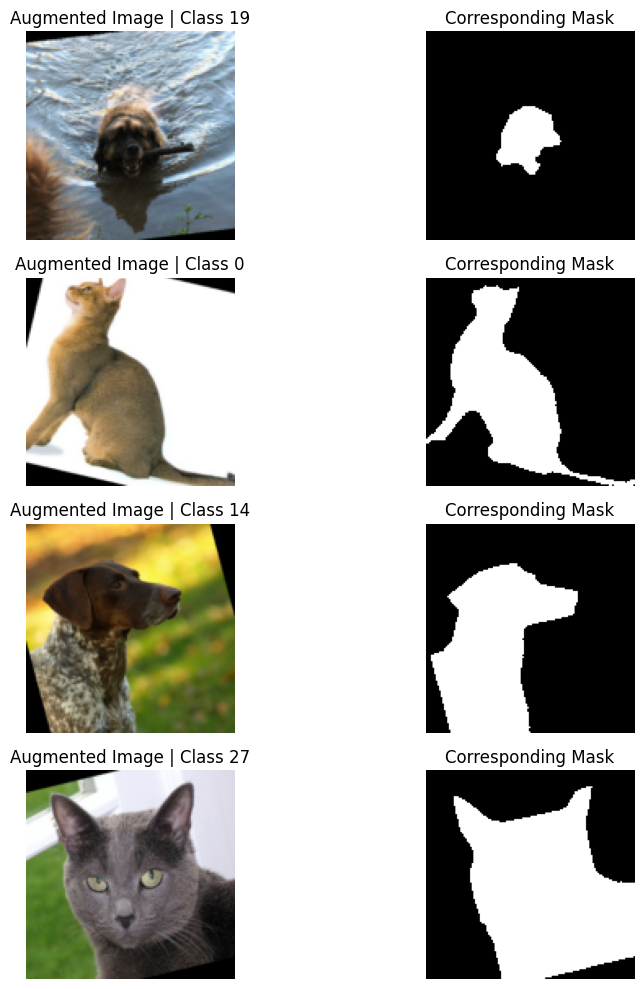

In [33]:
# ============================================================
# SHOW GEOMETRIC AUGMENTATION EXAMPLES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(4):

    image, label, mask = train_dataset_B[i]

    # Undo normalization
    display_image = image * 0.5 + 0.5

    plt.subplot(4, 2, 2*i + 1)

    plt.imshow(
        display_image
        .permute(1, 2, 0)
        .clamp(0, 1)
    )

    plt.title(
        f"Augmented Image | Class {label.item()}"
    )

    plt.axis("off")

    plt.subplot(4, 2, 2*i + 2)

    plt.imshow(
        mask.squeeze(),
        cmap="gray"
    )

    plt.title("Corresponding Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# FRESH MODEL FOR EXPERIMENT B
# ============================================================

model_B = MultiTaskCNN(
    num_classes=37
).to(device)

optimizer_B = torch.optim.Adam(
    model_B.parameters(),
    lr=1e-3
)

print("Experiment B model initialized.")

Experiment B model initialized.


In [35]:
# ============================================================
# TRAIN EXPERIMENT B
# ============================================================

NUM_EPOCHS = 25

history_B = {
    "train_total": [],
    "val_total": [],
    "train_cls": [],
    "val_cls": [],
    "train_seg": [],
    "val_seg": []
}

best_val_loss_B = float("inf")
BEST_MODEL_PATH_B = "best_multitask_expB.pth"


for epoch in range(1, NUM_EPOCHS + 1):

    train_total, train_cls, train_seg = run_epoch(
        model_B,
        train_loader_B,
        optimizer_B
    )

    val_total, val_cls, val_seg = run_epoch(
        model_B,
        val_loader_B,
        optimizer=None
    )

    history_B["train_total"].append(train_total)
    history_B["val_total"].append(val_total)

    history_B["train_cls"].append(train_cls)
    history_B["val_cls"].append(val_cls)

    history_B["train_seg"].append(train_seg)
    history_B["val_seg"].append(val_seg)

    if val_total < best_val_loss_B:

        best_val_loss_B = val_total

        torch.save(
            model_B.state_dict(),
            BEST_MODEL_PATH_B
        )

        marker = " <-- Best model saved"

    else:
        marker = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Total: {train_total:.4f} | "
        f"Val Total: {val_total:.4f} | "
        f"Train Cls: {train_cls:.4f} | "
        f"Val Cls: {val_cls:.4f} | "
        f"Train Seg: {train_seg:.4f} | "
        f"Val Seg: {val_seg:.4f}"
        f"{marker}"
    )


model_B.load_state_dict(
    torch.load(
        BEST_MODEL_PATH_B,
        map_location=device
    )
)

print("\nExperiment B training completed.")
print(
    f"Best Validation Loss: "
    f"{best_val_loss_B:.4f}"
)

Epoch 01/25 | Train Total: 4.5235 | Val Total: 4.6780 | Train Cls: 3.5041 | Val Cls: 3.6893 | Train Seg: 1.0194 | Val Seg: 0.9887 <-- Best model saved
Epoch 02/25 | Train Total: 4.0157 | Val Total: 4.3020 | Train Cls: 3.2205 | Val Cls: 3.4317 | Train Seg: 0.7952 | Val Seg: 0.8703 <-- Best model saved
Epoch 03/25 | Train Total: 3.6974 | Val Total: 3.8209 | Train Cls: 2.9897 | Val Cls: 3.1251 | Train Seg: 0.7077 | Val Seg: 0.6959 <-- Best model saved
Epoch 04/25 | Train Total: 3.5330 | Val Total: 3.7125 | Train Cls: 2.8554 | Val Cls: 3.0437 | Train Seg: 0.6776 | Val Seg: 0.6688 <-- Best model saved
Epoch 05/25 | Train Total: 3.3218 | Val Total: 3.6095 | Train Cls: 2.6954 | Val Cls: 2.8404 | Train Seg: 0.6264 | Val Seg: 0.7691 <-- Best model saved
Epoch 06/25 | Train Total: 3.1680 | Val Total: 4.2498 | Train Cls: 2.5628 | Val Cls: 3.5027 | Train Seg: 0.6052 | Val Seg: 0.7471
Epoch 07/25 | Train Total: 2.9909 | Val Total: 3.5481 | Train Cls: 2.4194 | Val Cls: 2.9666 | Train Seg: 0.5716 | V

In [36]:
# ============================================================
# EVALUATE EXPERIMENT B
# ============================================================

# ----------------------------
# Classification Accuracy
# ----------------------------

model_B.eval()

correct_B = 0
total_B = 0

all_labels_B = []
all_predictions_B = []

with torch.no_grad():

    for images, labels, masks in test_loader_B:

        images = images.to(device)
        labels = labels.to(device)

        class_logits, _ = model_B(images)

        predictions = torch.argmax(
            class_logits,
            dim=1
        )

        correct_B += (
            predictions == labels
        ).sum().item()

        total_B += labels.size(0)

        all_labels_B.extend(
            labels.cpu().numpy()
        )

        all_predictions_B.extend(
            predictions.cpu().numpy()
        )

test_accuracy_B = correct_B / total_B


# ----------------------------
# Segmentation Metrics
# ----------------------------

all_ious_B = []
all_dices_B = []

with torch.no_grad():

    for images, labels, masks in test_loader_B:

        images = images.to(device)
        masks = masks.to(device)

        _, seg_logits = model_B(images)

        pred_masks = (
            torch.sigmoid(seg_logits) >= 0.5
        ).float()

        iou = compute_iou(
            pred_masks,
            masks
        )

        dice = compute_dice(
            pred_masks,
            masks
        )

        all_ious_B.extend(
            iou.cpu().numpy()
        )

        all_dices_B.extend(
            dice.cpu().numpy()
        )

mean_iou_B = np.mean(all_ious_B)
mean_dice_B = np.mean(all_dices_B)


# ----------------------------
# Print Results
# ----------------------------

print("EXPERIMENT B RESULTS")
print("=" * 45)

print(
    f"Best Validation Loss         : "
    f"{best_val_loss_B:.4f}"
)

print(
    f"Test Classification Accuracy : "
    f"{test_accuracy_B * 100:.2f}%"
)

print(
    f"Mean Test IoU                : "
    f"{mean_iou_B:.4f}"
)

print(
    f"Mean Test Dice               : "
    f"{mean_dice_B:.4f}"
)

print("=" * 45)

EXPERIMENT B RESULTS
Best Validation Loss         : 2.1620
Test Classification Accuracy : 42.74%
Mean Test IoU                : 0.7279
Mean Test Dice               : 0.8279


Experiment C — Geometric + Appearance Augmentation.

In [38]:
# ============================================================
# QUESTION 2 - EXPERIMENT C
# GEOMETRIC + APPEARANCE AUGMENTATION
# ============================================================

import random
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.transforms import RandomResizedCrop


class PetMultiTaskDatasetAugC(Dataset):

    def __init__(
        self,
        root="./data",
        split="trainval",
        image_size=128,
        download=True,
        augment=False
    ):

        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types=("category", "segmentation"),
            download=download
        )

        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, (label, mask) = self.dataset[idx]

        # ----------------------------------------------------
        # GEOMETRIC AUGMENTATION
        # Apply identically to image and mask
        # ----------------------------------------------------
        if self.augment:

            # Random horizontal flip
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random rotation
            angle = random.uniform(-15, 15)

            image = TF.rotate(
                image,
                angle=angle,
                interpolation=InterpolationMode.BILINEAR,
                fill=0
            )

            mask = TF.rotate(
                mask,
                angle=angle,
                interpolation=InterpolationMode.NEAREST,
                fill=2
            )

            # Random resized crop
            i, j, h, w = RandomResizedCrop.get_params(
                image,
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1)
            )

            image = TF.resized_crop(
                image,
                i, j, h, w,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
                antialias=True
            )

            mask = TF.resized_crop(
                mask,
                i, j, h, w,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.NEAREST
            )

            # ------------------------------------------------
            # APPEARANCE AUGMENTATION
            # Apply ONLY to image
            # ------------------------------------------------

            brightness_factor = random.uniform(0.8, 1.2)
            contrast_factor = random.uniform(0.8, 1.2)
            saturation_factor = random.uniform(0.8, 1.2)

            image = TF.adjust_brightness(
                image,
                brightness_factor
            )

            image = TF.adjust_contrast(
                image,
                contrast_factor
            )

            image = TF.adjust_saturation(
                image,
                saturation_factor
            )

        else:

            image = TF.resize(
                image,
                [self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
                antialias=True
            )

            mask = TF.resize(
                mask,
                [self.image_size, self.image_size],
                interpolation=InterpolationMode.NEAREST
            )

        # ----------------------------------------------------
        # IMAGE -> TENSOR + NORMALIZATION
        # ----------------------------------------------------

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )

        # ----------------------------------------------------
        # MASK -> BINARY
        # ----------------------------------------------------

        mask = np.array(mask)

        mask = (mask == 1).astype(np.float32)

        mask = torch.from_numpy(mask).unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label, mask

In [39]:
# ============================================================
# EXPERIMENT C DATALOADERS
# SAME SPLIT AS A AND B
# ============================================================

IMAGE_SIZE = 128
BATCH_SIZE = 32
SEED = 42

trainval_augC_dataset = PetMultiTaskDatasetAugC(
    root="./data",
    split="trainval",
    image_size=IMAGE_SIZE,
    download=True,
    augment=True
)

trainval_cleanC_dataset = PetMultiTaskDatasetAugC(
    root="./data",
    split="trainval",
    image_size=IMAGE_SIZE,
    download=True,
    augment=False
)

test_dataset_C = PetMultiTaskDatasetAugC(
    root="./data",
    split="test",
    image_size=IMAGE_SIZE,
    download=True,
    augment=False
)

num_samples = len(trainval_augC_dataset)

train_size = int(0.8 * num_samples)
val_size = num_samples - train_size

generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    num_samples,
    generator=generator
).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset_C = Subset(
    trainval_augC_dataset,
    train_indices
)

val_dataset_C = Subset(
    trainval_cleanC_dataset,
    val_indices
)

train_loader_C = DataLoader(
    train_dataset_C,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_C = DataLoader(
    val_dataset_C,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_C = DataLoader(
    test_dataset_C,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Experiment C loaders created.")
print("Training samples:", len(train_dataset_C))
print("Validation samples:", len(val_dataset_C))
print("Test samples:", len(test_dataset_C))

Experiment C loaders created.
Training samples: 2944
Validation samples: 736
Test samples: 3669


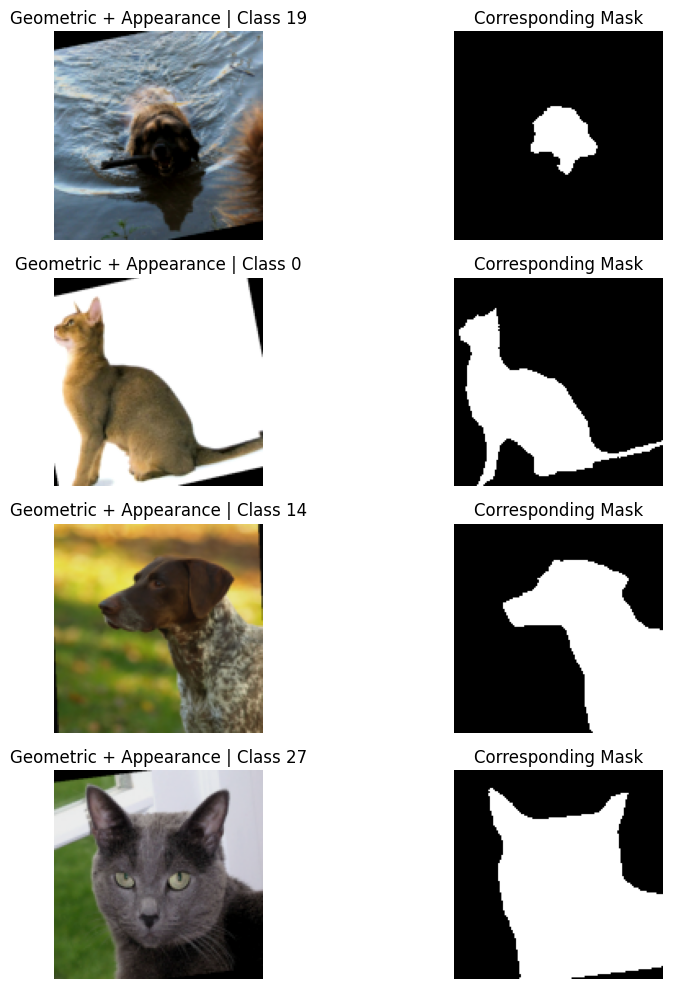

In [40]:
# ============================================================
# SHOW EXPERIMENT C AUGMENTATION EXAMPLES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(4):

    image, label, mask = train_dataset_C[i]

    display_image = image * 0.5 + 0.5

    plt.subplot(4, 2, 2*i + 1)

    plt.imshow(
        display_image
        .permute(1, 2, 0)
        .clamp(0, 1)
    )

    plt.title(
        f"Geometric + Appearance | Class {label.item()}"
    )

    plt.axis("off")

    plt.subplot(4, 2, 2*i + 2)

    plt.imshow(
        mask.squeeze(),
        cmap="gray"
    )

    plt.title("Corresponding Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

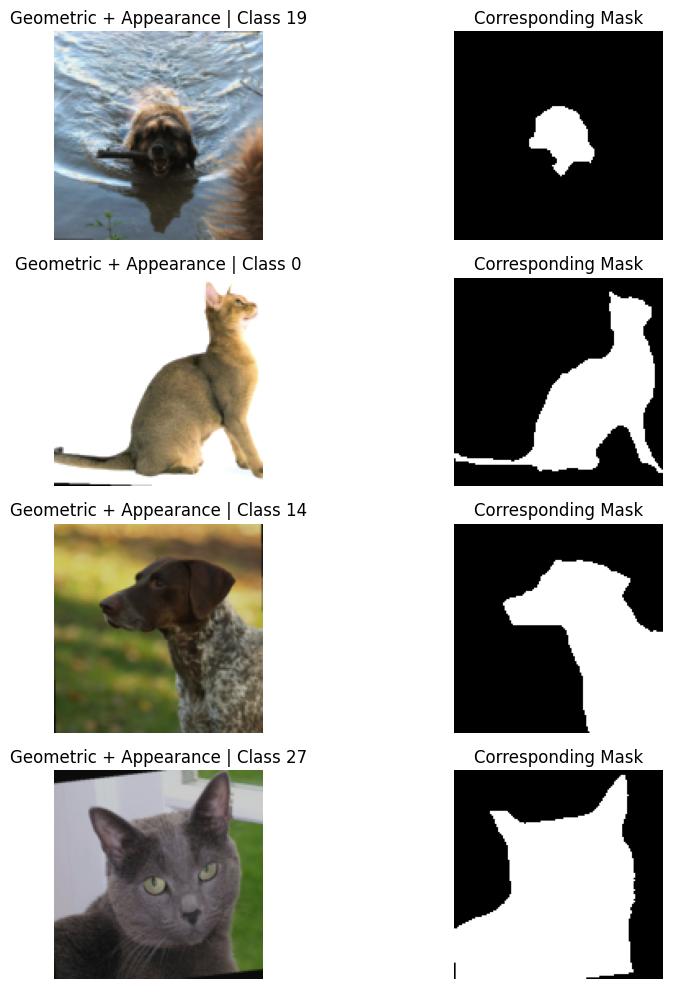

In [41]:
# ============================================================
# SHOW EXPERIMENT C AUGMENTATION EXAMPLES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(4):

    image, label, mask = train_dataset_C[i]

    display_image = image * 0.5 + 0.5

    plt.subplot(4, 2, 2*i + 1)

    plt.imshow(
        display_image
        .permute(1, 2, 0)
        .clamp(0, 1)
    )

    plt.title(
        f"Geometric + Appearance | Class {label.item()}"
    )

    plt.axis("off")

    plt.subplot(4, 2, 2*i + 2)

    plt.imshow(
        mask.squeeze(),
        cmap="gray"
    )

    plt.title("Corresponding Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# FRESH MODEL FOR EXPERIMENT C
# ============================================================

model_C = MultiTaskCNN(
    num_classes=37
).to(device)

optimizer_C = torch.optim.Adam(
    model_C.parameters(),
    lr=1e-3
)

print("Experiment C model initialized.")

Experiment C model initialized.


In [43]:
# ============================================================
# TRAIN EXPERIMENT C
# ============================================================

NUM_EPOCHS = 25

history_C = {
    "train_total": [],
    "val_total": [],
    "train_cls": [],
    "val_cls": [],
    "train_seg": [],
    "val_seg": []
}

best_val_loss_C = float("inf")
BEST_MODEL_PATH_C = "best_multitask_expC.pth"


for epoch in range(1, NUM_EPOCHS + 1):

    train_total, train_cls, train_seg = run_epoch(
        model_C,
        train_loader_C,
        optimizer_C
    )

    val_total, val_cls, val_seg = run_epoch(
        model_C,
        val_loader_C,
        optimizer=None
    )

    history_C["train_total"].append(train_total)
    history_C["val_total"].append(val_total)

    history_C["train_cls"].append(train_cls)
    history_C["val_cls"].append(val_cls)

    history_C["train_seg"].append(train_seg)
    history_C["val_seg"].append(val_seg)

    if val_total < best_val_loss_C:

        best_val_loss_C = val_total

        torch.save(
            model_C.state_dict(),
            BEST_MODEL_PATH_C
        )

        marker = " <-- Best model saved"

    else:
        marker = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Total: {train_total:.4f} | "
        f"Val Total: {val_total:.4f} | "
        f"Train Cls: {train_cls:.4f} | "
        f"Val Cls: {val_cls:.4f} | "
        f"Train Seg: {train_seg:.4f} | "
        f"Val Seg: {val_seg:.4f}"
        f"{marker}"
    )


model_C.load_state_dict(
    torch.load(
        BEST_MODEL_PATH_C,
        map_location=device
    )
)

print("\nExperiment C training completed.")
print(
    f"Best Validation Loss: "
    f"{best_val_loss_C:.4f}"
)

Epoch 01/25 | Train Total: 4.6524 | Val Total: 4.7061 | Train Cls: 3.5699 | Val Cls: 3.5564 | Train Seg: 1.0825 | Val Seg: 1.1497 <-- Best model saved
Epoch 02/25 | Train Total: 4.2603 | Val Total: 4.1995 | Train Cls: 3.3759 | Val Cls: 3.3474 | Train Seg: 0.8844 | Val Seg: 0.8521 <-- Best model saved
Epoch 03/25 | Train Total: 3.9472 | Val Total: 3.9618 | Train Cls: 3.1967 | Val Cls: 3.2690 | Train Seg: 0.7505 | Val Seg: 0.6928 <-- Best model saved
Epoch 04/25 | Train Total: 3.7167 | Val Total: 4.0279 | Train Cls: 3.0211 | Val Cls: 3.3231 | Train Seg: 0.6956 | Val Seg: 0.7049
Epoch 05/25 | Train Total: 3.5458 | Val Total: 3.5842 | Train Cls: 2.8818 | Val Cls: 2.9651 | Train Seg: 0.6640 | Val Seg: 0.6191 <-- Best model saved
Epoch 06/25 | Train Total: 3.3440 | Val Total: 3.3814 | Train Cls: 2.7320 | Val Cls: 2.8418 | Train Seg: 0.6120 | Val Seg: 0.5396 <-- Best model saved
Epoch 07/25 | Train Total: 3.2538 | Val Total: 4.6068 | Train Cls: 2.6401 | Val Cls: 4.0252 | Train Seg: 0.6137 | V

In [44]:
# ============================================================
# EVALUATE EXPERIMENT C
# ============================================================

model_C.eval()

# ------------------------------------------------------------
# Classification Accuracy
# ------------------------------------------------------------

correct_C = 0
total_C = 0

all_labels_C = []
all_predictions_C = []

with torch.no_grad():

    for images, labels, masks in test_loader_C:

        images = images.to(device)
        labels = labels.to(device)

        class_logits, _ = model_C(images)

        predictions = torch.argmax(
            class_logits,
            dim=1
        )

        correct_C += (
            predictions == labels
        ).sum().item()

        total_C += labels.size(0)

        all_labels_C.extend(
            labels.cpu().numpy()
        )

        all_predictions_C.extend(
            predictions.cpu().numpy()
        )

test_accuracy_C = correct_C / total_C


# ------------------------------------------------------------
# Segmentation Metrics
# ------------------------------------------------------------

all_ious_C = []
all_dices_C = []

with torch.no_grad():

    for images, labels, masks in test_loader_C:

        images = images.to(device)
        masks = masks.to(device)

        _, seg_logits = model_C(images)

        pred_masks = (
            torch.sigmoid(seg_logits) >= 0.5
        ).float()

        iou = compute_iou(
            pred_masks,
            masks
        )

        dice = compute_dice(
            pred_masks,
            masks
        )

        all_ious_C.extend(
            iou.cpu().numpy()
        )

        all_dices_C.extend(
            dice.cpu().numpy()
        )

mean_iou_C = np.mean(all_ious_C)
mean_dice_C = np.mean(all_dices_C)


# ------------------------------------------------------------
# Print Experiment C Results
# ------------------------------------------------------------

print("EXPERIMENT C RESULTS")
print("=" * 45)

print(
    f"Best Validation Loss         : "
    f"{best_val_loss_C:.4f}"
)

print(
    f"Test Classification Accuracy : "
    f"{test_accuracy_C * 100:.2f}%"
)

print(
    f"Mean Test IoU                : "
    f"{mean_iou_C:.4f}"
)

print(
    f"Mean Test Dice               : "
    f"{mean_dice_C:.4f}"
)

print("=" * 45)

EXPERIMENT C RESULTS
Best Validation Loss         : 2.3698
Test Classification Accuracy : 38.76%
Mean Test IoU                : 0.7367
Mean Test Dice               : 0.8351
